# Popularity Bias Analysis

Notebook de análisis que carga artefactos pre-computados para evitar re-ejecutar la simulación completa.
Ejecuta primero `popularity_bias.ipynb` para generar los artefactos en `../artifacts/`.

In [2]:
import sys
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

from src.eval.simulation_metrics import evaluate_run_awpd_observations

ARTIFACTS = ROOT / "artifacts"
assert ARTIFACTS.exists(), f"Artifacts dir not found: {ARTIFACTS}. Run popularity_bias.ipynb first."

## Cargar artefactos

In [3]:
ratings_long = pd.read_parquet(ARTIFACTS / "ratings_long.parquet")

with open(ARTIFACTS / "ratings_by_model.pkl", "rb") as f:
    ratings_by_model = pickle.load(f)

data = np.load(ARTIFACTS / "simulation_state.npz")
uc         = data["user_clusters"]
ic         = data["item_clusters"]
A          = data["affinity"]
popularity = data["popularity"]
U          = int(data["num_users"][0])

print("ratings_long:", ratings_long.shape)
print("models:", list(ratings_by_model.keys()))
print("runs per model:", {m: len(v) for m, v in ratings_by_model.items()})
print("U:", U, "| uc shape:", uc.shape, "| ic shape:", ic.shape)

ratings_long: (60000, 3)
models: ['BaselineOnly', 'SVD', 'Random']
runs per model: {'BaselineOnly': 40, 'SVD': 40, 'Random': 40}
U: 3000 | uc shape: (3000,) | ic shape: (1682,)


## Calcular AWPD

In [4]:
obs_df = evaluate_run_awpd_observations(
    ratings_long=ratings_long,
    ratings_by_model=ratings_by_model,
    user_clusters=uc,
    item_clusters=ic,
    affinity=A,
    num_users=U,
    popularity=popularity,
)

# aggregated view: one row per (Model, Run)
awpd_df = obs_df.groupby(["Model", "Run"])[["AWPD", "PopDeviation", "Misalignment"]].mean().reset_index()

print("obs_df:", obs_df.shape)
obs_df.head(5)

obs_df: (360000, 6)


,Model,Run,UserID,AWPD,PopDeviation,Misalignment
0,BaselineOnly,0,0,0.804505,0.644118,0.450712
1,BaselineOnly,0,1,0.756066,0.661765,0.355031
2,BaselineOnly,0,2,0.781627,0.644118,0.433462
3,BaselineOnly,0,3,0.779608,0.661765,0.408494
4,BaselineOnly,0,4,0.784998,0.661765,0.413514


In [5]:
print(obs_df.shape)
obs_df[obs_df["Model"] == "Random"].head(10)

(360000, 6)


,Model,Run,UserID,AWPD,PopDeviation,Misalignment
240000,Random,0,0,0.749785,0.432353,0.564909
240001,Random,0,1,0.671776,0.491176,0.402922
240002,Random,0,2,0.725112,0.552941,0.433425
240003,Random,0,3,0.685502,0.538235,0.418399
240004,Random,0,4,0.741197,0.535294,0.509648
240005,Random,0,5,0.727244,0.567647,0.443467
240006,Random,0,6,0.676313,0.485294,0.458541
240007,Random,0,7,0.754577,0.441176,0.594716
240008,Random,0,8,0.847036,0.652941,0.534029
240009,Random,0,9,0.723012,0.473529,0.523972


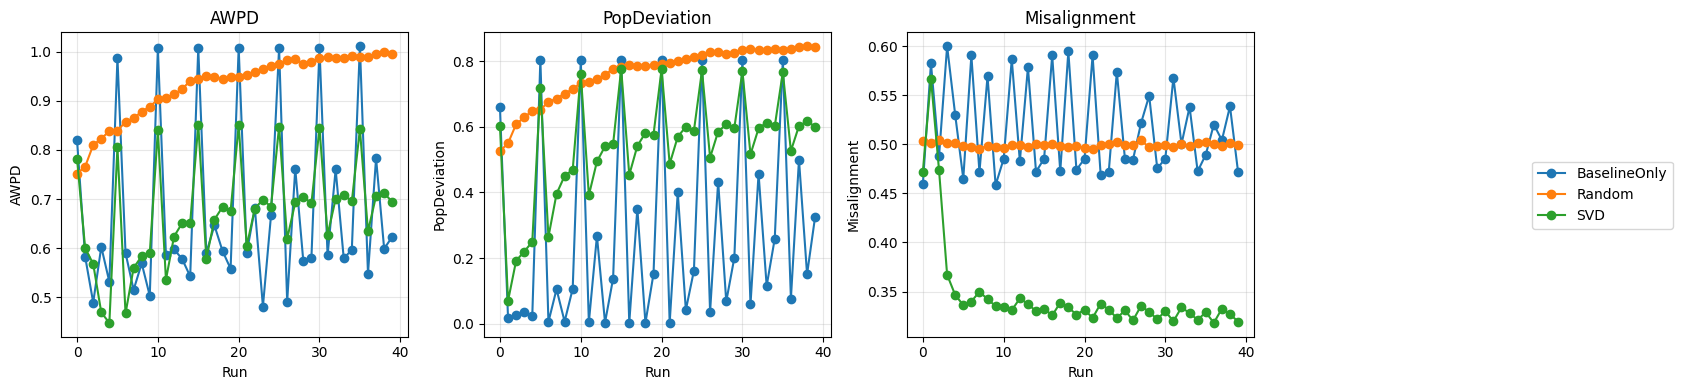

In [6]:
awpd_metrics_to_plot = ["AWPD", "PopDeviation", "Misalignment"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)

for ax, metric in zip(axes, awpd_metrics_to_plot):
    for model, sub in awpd_df.groupby("Model"):
        sub = sub.sort_values("Run")
        ax.plot(sub["Run"], sub[metric], marker="o", label=model)
    ax.set_title(metric)
    ax.set_xlabel("Run")
    ax.set_ylabel(metric)
    ax.grid(True, alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

## PopDeviation vs Misalignment

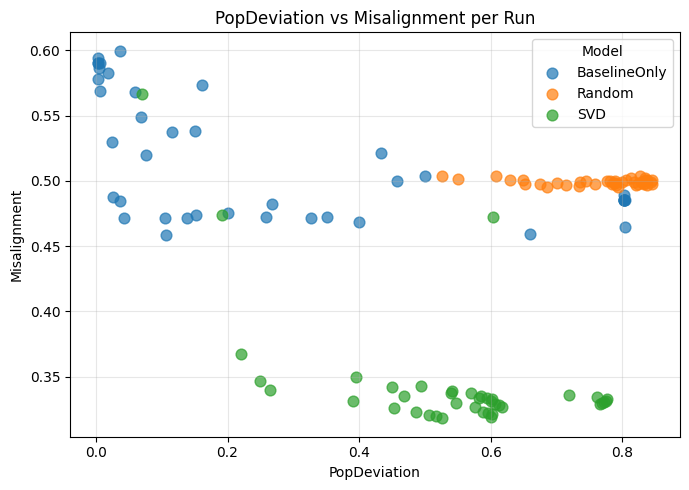

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))

for model, sub in awpd_df.groupby("Model"):
    ax.scatter(sub["PopDeviation"], sub["Misalignment"], label=model, alpha=0.70, s=60)

ax.set_xlabel("PopDeviation")
ax.set_ylabel("Misalignment")
ax.set_title("PopDeviation vs Misalignment per Run")
ax.legend(title="Model")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

C:\Users\mrari\AppData\Local\Temp\ipykernel_25060\3761590929.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(clusters))


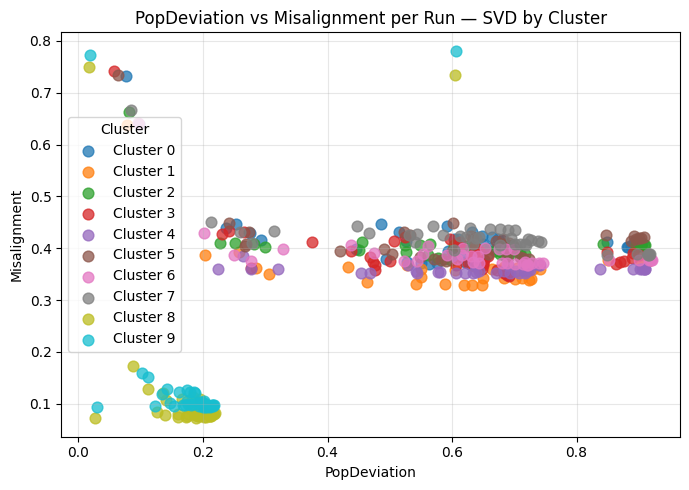

In [8]:

# PopDeviation vs Misalignment per Run — SVD only, coloured by user cluster
svd_obs = obs_df[obs_df["Model"] == "SVD"].copy()
svd_obs["Cluster"] = uc[svd_obs["UserID"].values]

# One point per (Run, Cluster): mean over users in that cluster for that run
svd_cluster = (
    svd_obs
    .groupby(["Run", "Cluster"])[["PopDeviation", "Misalignment"]]
    .mean()
    .reset_index()
)

clusters = sorted(svd_cluster["Cluster"].unique())
cmap = plt.cm.get_cmap("tab10", len(clusters))

fig, ax = plt.subplots(figsize=(7, 5))
for i, c in enumerate(clusters):
    sub = svd_cluster[svd_cluster["Cluster"] == c]
    ax.scatter(sub["PopDeviation"], sub["Misalignment"],
               label=f"Cluster {c}", color=cmap(i), alpha=0.75, s=60)

ax.set_xlabel("PopDeviation")
ax.set_ylabel("Misalignment")
ax.set_title("PopDeviation vs Misalignment per Run — SVD by Cluster")
ax.legend(title="Cluster")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


C:\Users\mrari\AppData\Local\Temp\ipykernel_25060\1371174444.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(clusters))


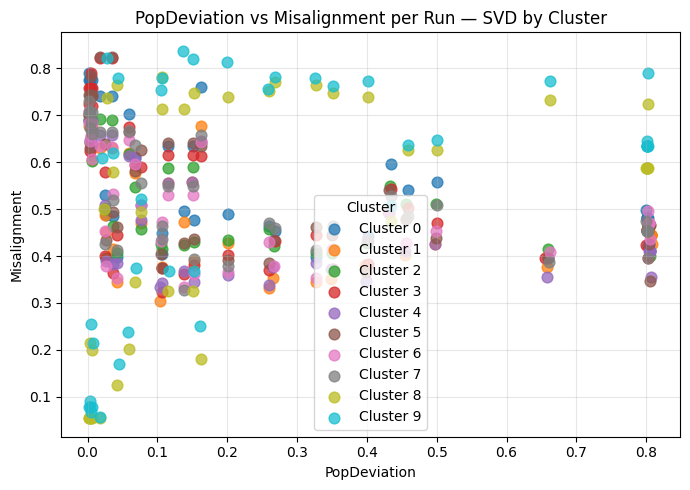

In [9]:

# PopDeviation vs Misalignment per Run — SVD only, coloured by user cluster
svd_obs = obs_df[obs_df["Model"] == "BaselineOnly"].copy()
svd_obs["Cluster"] = uc[svd_obs["UserID"].values]

# One point per (Run, Cluster): mean over users in that cluster for that run
svd_cluster = (
    svd_obs
    .groupby(["Run", "Cluster"])[["PopDeviation", "Misalignment"]]
    .mean()
    .reset_index()
)

clusters = sorted(svd_cluster["Cluster"].unique())
cmap = plt.cm.get_cmap("tab10", len(clusters))

fig, ax = plt.subplots(figsize=(7, 5))
for i, c in enumerate(clusters):
    sub = svd_cluster[svd_cluster["Cluster"] == c]
    ax.scatter(sub["PopDeviation"], sub["Misalignment"],
               label=f"Cluster {c}", color=cmap(i), alpha=0.75, s=60)

ax.set_xlabel("PopDeviation")
ax.set_ylabel("Misalignment")
ax.set_title("PopDeviation vs Misalignment per Run — SVD by Cluster")
ax.legend(title="Cluster")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


C:\Users\mrari\AppData\Local\Temp\ipykernel_25060\961971916.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(clusters))


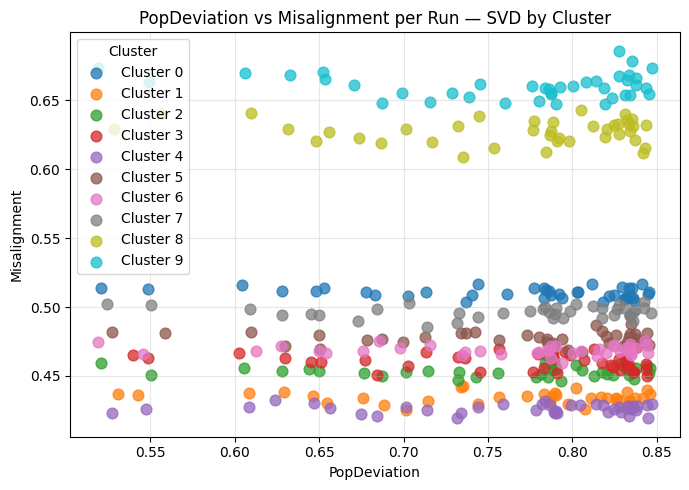

In [10]:

# PopDeviation vs Misalignment per Run — SVD only, coloured by user cluster
svd_obs = obs_df[obs_df["Model"] == "Random"].copy()
svd_obs["Cluster"] = uc[svd_obs["UserID"].values]

# One point per (Run, Cluster): mean over users in that cluster for that run
svd_cluster = (
    svd_obs
    .groupby(["Run", "Cluster"])[["PopDeviation", "Misalignment"]]
    .mean()
    .reset_index()
)

clusters = sorted(svd_cluster["Cluster"].unique())
cmap = plt.cm.get_cmap("tab10", len(clusters))

fig, ax = plt.subplots(figsize=(7, 5))
for i, c in enumerate(clusters):
    sub = svd_cluster[svd_cluster["Cluster"] == c]
    ax.scatter(sub["PopDeviation"], sub["Misalignment"],
               label=f"Cluster {c}", color=cmap(i), alpha=0.75, s=60)

ax.set_xlabel("PopDeviation")
ax.set_ylabel("Misalignment")
ax.set_title("PopDeviation vs Misalignment per Run — SVD by Cluster")
ax.legend(title="Cluster")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


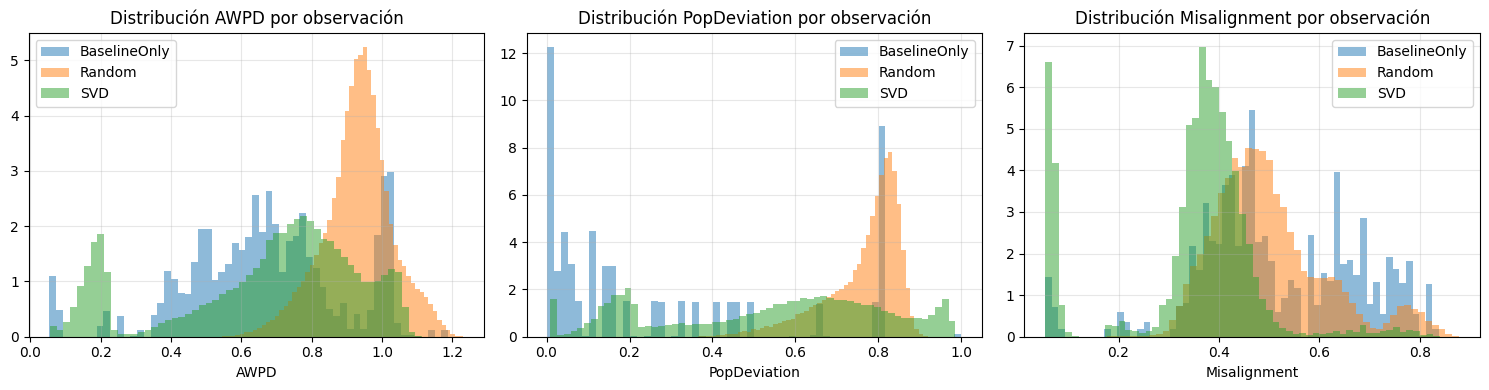

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, metric in zip(axes, ["AWPD", "PopDeviation", "Misalignment"]):
    for model, sub in obs_df.groupby("Model"):
        ax.hist(sub[metric], bins=60, alpha=0.5, label=model, density=True)
    ax.set_title(f"Distribución {metric} por observación")
    ax.set_xlabel(metric)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()